[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/langchain-ai/langchain-academy/blob/main/module-2/chatbot-summarization.ipynb) [![Open in LangChain Academy](https://cdn.prod.website-files.com/65b8cd72835ceeacd4449a53/66e9eba12c7b7688aa3dbb5e_LCA-badge-green.svg)](https://academy.langchain.com/courses/take/intro-to-langgraph/lessons/58239436-lesson-5-chatbot-w-summarizing-messages-and-memory)

# Chatbot with message summarization

## Review

그래프 상태 스키마와 리듀서를 커스터마이징하는 방법을 다루었습니다.

또한 그래프 상태에서 메시지를 트리밍하거나 필터링하는 여러 가지 방법을 보여주었습니다. 

## Goals

이제 한 단계 더 나아가 보겠습니다!  

단순히 메시지를 잘라내거나 필터링하는 대신, 대화의 진행 상황을 요약해 보여주는 방법을 LLM을 활용해 보여드리겠습니다.
 
이를 통해 트리밍이나 필터링으로 대화 전체를 제거하는 대신 압축된 형태로 보존할 수 있습니다.

이 요약 기능을 간단한 챗봇에 통합해 보겠습니다.  

또한 해당 챗봇에 메모리 기능을 탑재하여 높은 토큰 비용이나 지연 시간 없이 장시간 지속되는 대화를 지원할 것입니다. 

In [1]:
# %%capture --no-stderr
# %pip install --quiet -U langchain_core langgraph langchain_openai

In [2]:
# import os, getpass

# def _set_env(var: str):
#     if not os.environ.get(var):
#         os.environ[var] = getpass.getpass(f"{var}: ")

# _set_env("OPENAI_API_KEY")

from dotenv import load_dotenv

load_dotenv("../../.env")

True

We'll use [LangSmith](https://docs.langchain.com/langsmith/home) for  [tracing](https://docs.langchain.com/langsmith/observability-concepts).

In [3]:
# _set_env("LANGSMITH_API_KEY")
# os.environ["LANGSMITH_TRACING"] = "true"
# os.environ["LANGSMITH_PROJECT"] = "langchain-academy"

In [4]:
from langchain_openai import ChatOpenAI
model = ChatOpenAI(model="gpt-4o",temperature=0)

이전과 마찬가지로 `MessagesState`를 사용할 것입니다.

내장된 `messages` 키 외에도 이제 사용자 정의 키(`summary`)를 포함시킬 것입니

In [5]:
from langgraph.graph import MessagesState
class State(MessagesState):
    summary: str

LLM 호출 노드를 정의하여, 요약본이 존재할 경우 이를 프롬프트에 통합하도록 하겠습니다.

In [6]:
from langchain_core.messages import SystemMessage, HumanMessage, RemoveMessage

# Define the logic to call the model
def call_model(state: State):
    
    # Get summary if it exists
    summary = state.get("summary", "")

    # 요약내용이 있으면 메시지에 추가한다.
    if summary:
        
        # Add summary to system message
        system_message = f"Summary of conversation earlier: {summary}"

        # Append summary to any newer messages
        messages = [SystemMessage(content=system_message)] + state["messages"]
    
    else:
        messages = state["messages"]
    
    response = model.invoke(messages)
    return {"messages": response}

요약문을 생성하는 노드를 정의하겠습니다.

참고: 요약문 생성 후 상태를 필터링하기 위해 `RemoveMessage`를 사용할 것입니다.

In [7]:
def summarize_conversation(state: State):
    
    # First, we get any existing summary
    summary = state.get("summary", "")

    # 요약 프롬프트 생성
    if summary:
        
        # A summary already exists
        summary_message = (
            f"지금까지의 대화 요약은 다음과 같습니다:: {summary}\n\n"
            "위의 새로운 메시지를 고려하여 요약을 확장하십시오:"
        )
        
    else:
        summary_message = "위의 대화 내용을 요약하세요."

    # Add prompt to our history
    messages = state["messages"] + [HumanMessage(content=summary_message)]
    response = model.invoke(messages)
    
    # 최근 2개 메시지를 제외하고 모두 삭제
    delete_messages = [RemoveMessage(id=m.id) for m in state["messages"][:-2]]
    return {"summary": response.content, "messages": delete_messages}

대화 길이에 따라 요약문을 생성할지 여부를 결정하기 위한 conditional edge를 추가하겠습니다.

In [8]:
from langgraph.graph import END
from typing_extensions import Literal
# Determine whether to end or summarize the conversation
def should_continue(state: State) -> Literal ["summarize_conversation",END]:
    
    """Return the next node to execute."""
    
    messages = state["messages"]
    
    # 메시지가 6개 이상이면 대화를 요약함
    if len(messages) > 6:
        return "summarize_conversation"
    
    # Otherwise we can just end
    return END

## Adding memory

[state는 일시적](https://github.com/langchain-ai/langgraph/discussions/352#discussioncomment-9291220)이며 단일 그래프 실행에 국한됨을 상기하십시오.

이로 인해 중단이 발생하는 다중 회화(multi-turn conversation)를 구현하는 데 한계가 있습니다.

모듈 1 마지막에서 소개한 바와 같이, [지속성(persistence)](https://docs.langchain.com/oss/python/langgraph/persistence)을 활용해 이 문제를 해결할 수 있습니다!

LangGraph는 체크포인트(checkpointer)를 사용해 각 단계 후 그래프 상태를 자동 저장합니다.

이 내장 지속성 계층은 메모리를 제공하여 LangGraph가 마지막 상태 업데이트 시점부터 재개할 수 있게 합니다.

앞서 보여드렸듯이 가장 다루기 쉬운 방법 중 하나는 그래프 상태를 위한 인메모리 키-값 저장소인 `MemorySaver`입니다.

체크포인터로 그래프를 컴파일하기만 하면, 그래프에 메모리가 부여됩니다!

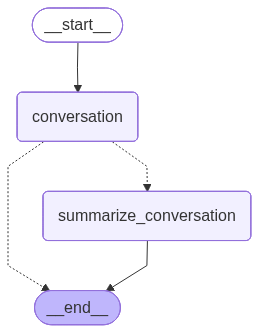

In [9]:
from IPython.display import Image, display
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph, START

# Define a new graph
workflow = StateGraph(State)
workflow.add_node("conversation", call_model)
workflow.add_node(summarize_conversation)

# Set the entrypoint as conversation
workflow.add_edge(START, "conversation")
workflow.add_conditional_edges("conversation", should_continue)
workflow.add_edge("summarize_conversation", END)

# Compile
memory = MemorySaver()
graph = workflow.compile(checkpointer=memory)
display(Image(graph.get_graph().draw_mermaid_png()))

## Threads

체크포인트기는 각 단계에서 state를 체크포인트로 저장합니다.

저장된 체크포인트는 대화의 `스레드`로 그룹화될 수 있습니다.

비유로 Slack을 생각해 보세요: 서로 다른 채널이 서로 다른 대화를 담습니다.

스레드는 Slack 채널과 유사하며, 그룹화된 상태 집합(예: 대화)을 포착합니다.

아래에서는 `configurable`을 사용하여 스레드 ID를 설정합니다.

![state.jpg](https://cdn.prod.website-files.com/65b8cd72835ceeacd4449a53/66dbadf3b379c2ee621adfd1_chatbot-summarization1.png)

In [10]:
# Create a thread
config = {"configurable": {"thread_id": "1"}}

# Start conversation
input_message = HumanMessage(content="안녕. 내이름은 유광명이야.")
output = graph.invoke({"messages": [input_message]}, config) 
for m in output['messages'][-1:]:
    m.pretty_print()

input_message = HumanMessage(content="내이름이 뭐야?")
output = graph.invoke({"messages": [input_message]}, config) 
for m in output['messages'][-1:]:
    m.pretty_print()

input_message = HumanMessage(content="나는 LA Dodgers를 좋아해!")
output = graph.invoke({"messages": [input_message]}, config) 
for m in output['messages'][-1:]:
    m.pretty_print()

================================== Ai Message ==================================

안녕하세요, 유광명님! 만나서 반갑습니다. 오늘 어떻게 도와드릴까요?
================================== Ai Message ==================================

당신의 이름은 유광명이라고 하셨습니다. 맞나요?
================================== Ai Message ==================================

LA 다저스를 좋아하시는군요! 다저스는 역사와 전통이 깊은 팀으로 많은 팬들에게 사랑받고 있죠. 최근 경기나 선수들 중에 특별히 관심 있는 부분이 있나요?


현재 메시지가 6개 이하이므로 상태 요약이 아직 없습니다.

이는 `should_continue`에서 설정되었습니다.

```
    # 메시지가 6개 이상이면 대화를 요약합니다
    if len(messages) > 6:
        return “summarize_conversation”
```

스레드가 있으므로 대화를 이어갈 수 있습니다.

In [11]:
graph.get_state(config).values.get("summary","")

''

스레드 ID가 포함된 `config`를 통해 이전에 기록된 상태에서 작업을 계속할 수 있습니다!

In [12]:
input_message = HumanMessage(content="나는 Mookie Betts를 좋아해, 가장 수비를 잘하지?")
output = graph.invoke({"messages": [input_message]}, config) 
for m in output['messages'][-1:]:
    m.pretty_print()

================================== Ai Message ==================================

무키 베츠는 정말 뛰어난 선수죠! 그는 특히 수비에서 매우 인상적인 모습을 보여주며, 골드 글러브 상을 여러 차례 수상한 바 있습니다. 그의 빠른 반사 신경과 정확한 송구 능력은 많은 팬들에게 감탄을 자아내죠. 공격에서도 강력한 모습을 보여주니, 다재다능한 선수라고 할 수 있습니다. 무키 베츠의 어떤 점이 가장 마음에 드시나요?


In [13]:
graph.get_state(config).values.get("summary","")

'유광명님은 LA 다저스를 좋아하며, 특히 무키 베츠를 좋아한다고 말씀하셨습니다. 무키 베츠는 뛰어난 수비 능력과 다재다능한 플레이로 많은 팬들에게 사랑받는 선수입니다.'

## LangSmith

Let's review the trace!